# Проект: Многоцелевая модель для NER + event-CLS

Этот ноутбук реализует multi-task модель для задач **NER (BIO, token-level)** и **CLS (document-level multihot событий/отношений)** на датасете NEREL.

## 1. Подготовка окружения

In [1]:
import os
import json
import random
import re
from collections import Counter
from typing import List, Dict, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/ubuntu/NEREL/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# Скачивание данных
!wget -q -O train.jsonl "https://huggingface.co/datasets/iluvvatar/NEREL/resolve/main/data/train.jsonl"
!wget -q -O dev.jsonl "https://huggingface.co/datasets/iluvvatar/NEREL/resolve/main/data/dev.jsonl"
!wget -q -O test.jsonl "https://huggingface.co/datasets/iluvvatar/NEREL/resolve/main/data/test.jsonl"
print("Данные скачаны.")

Данные скачаны.


In [4]:
def load_jsonl(path: str) -> List[dict]:
    """Загрузка JSONL файла."""
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return data

train_data = load_jsonl('train.jsonl')
dev_data = load_jsonl('dev.jsonl')
test_data = load_jsonl('test.jsonl')

print(f"Train: {len(train_data)}, Dev: {len(dev_data)}, Test: {len(test_data)}")

Train: 746, Dev: 94, Test: 93


## 2. EDA - Exploratory Data Analysis

In [5]:
train_data[:50]

[{'id': 0,
  'text': 'Пулеметы, автоматы и снайперские винтовки изъяты в арендуемом американцами доме в Бишкеке\n\n05/08/2008 10:35\n\nБИШКЕК, 5 августа /Новости-Грузия/. Правоохранительные органы Киргизии обнаружили в доме, арендуемом гражданами США в Бишкеке, пулеметы, автоматы и снайперские винтовки, сообщает во вторник пресс-служба МВД Киргизии.\n\n"В ходе проведения оперативно-профилактического мероприятия под кодовым названием "Арсенал" в новостройке Ынтымак, в доме, принадлежащем 66-летнему гражданину Киргизии и арендуемом гражданами США, обнаружены и изъяты: шесть крупнокалиберных пулеметов с оптическим прицелом и с приборами ночного видения, 26 автоматов калибра 5,56 миллиметра, два винчестера марки МОСВЕГА 12-го калибра, четыре ствола от крупнокалиберного пулемета, два подствольных гранатомета, четыре снайперские винтовки с оптическим прицелом защитного цвета, шесть пистолетов калибра 9 миллиметров марки Беретта, одна винтовка", - говорится в сообщении МВД.\n\nПресс-служба от

Подсчёт частот типов сущностей и отношений

In [6]:
# Парсеры из шаблона
def parse_entity_line(line: str):
    parts = line.split('\t')
    if len(parts) < 3:
        return None
    ent_id = parts[0].strip()
    type_pos = parts[1].strip()
    text = parts[2].strip() if len(parts) > 2 else ''
    m = re.match(r'(\S+)\s+(\d+)\s+(\d+)', type_pos)
    if not m:
        return None
    ent_type = m.group(1)
    start = int(m.group(2))
    end = int(m.group(3))
    return {'id': ent_id, 'type': ent_type, 'start': start, 'end': end, 'text': text}

def parse_relation_line(line: str):
    parts = line.split('\t')
    if len(parts) < 2:
        return None
    rel_id = parts[0].strip()
    body = parts[1].strip()
    m = re.match(r'(\S+)\s+Arg1:(\S+)\s+Arg2:(\S+)', body)
    if not m:
        return None
    rel_type = m.group(1)
    arg1 = m.group(2)
    arg2 = m.group(3)
    return {'id': rel_id, 'type': rel_type, 'arg1': arg1, 'arg2': arg2}

In [7]:
entity_types_counter = Counter()
relation_types_counter = Counter()
text_lengths = []
entities_per_doc = []

for doc in train_data:
    text_lengths.append(len(doc['text']))
    entities_per_doc.append(len(doc.get('entities', [])))

    for ent_line in doc.get('entities', []):
        ent = parse_entity_line(ent_line)
        if ent:
            entity_types_counter[ent['type']] += 1

    for rel_line in doc.get('relations', []):
        rel = parse_relation_line(rel_line)
        if rel:
            relation_types_counter[rel['type']] += 1

print(f"Уникальных типов сущностей: {len(entity_types_counter)}")
print(f"Уникальных типов отношений: {len(relation_types_counter)}")

Уникальных типов сущностей: 29
Уникальных типов отношений: 49


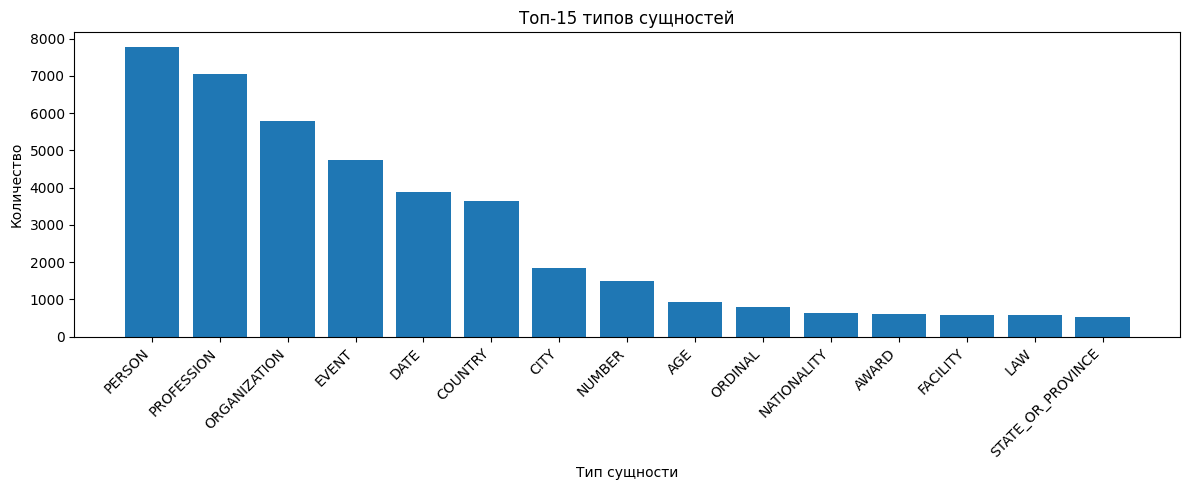

In [8]:
# Топ-15 типов сущностей
top_entities = entity_types_counter.most_common(15)
plt.figure(figsize=(12, 5))
plt.bar([x[0] for x in top_entities], [x[1] for x in top_entities])
plt.xticks(rotation=45, ha='right')
plt.title('Топ-15 типов сущностей')
plt.xlabel('Тип сущности')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

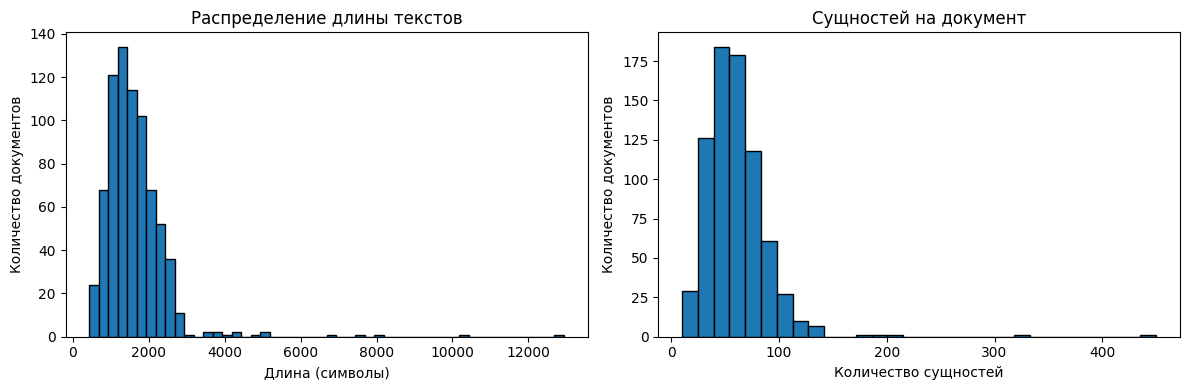

In [9]:
# Распределение длины текстов
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.title('Распределение длины текстов')
plt.xlabel('Длина (символы)')
plt.ylabel('Количество документов')

# Распределение количества сущностей на документ
plt.subplot(1, 2, 2)
plt.hist(entities_per_doc, bins=30, edgecolor='black')
plt.title('Сущностей на документ')
plt.xlabel('Количество сущностей')
plt.ylabel('Количество документов')
plt.tight_layout()
plt.show()

### Выводы EDA:

1. **Дисбаланс классов сущностей**: PERSON, PROFESSION, ORGANIZATION доминируют (5000-8000). Редкие типы (NATIONALITY, AWARD, FACILITY, LAW, STATE_OR_PROVINCE) встречаются в 10-15 раз реже — будут распознаваться хуже.

2. **Длина текстов**: Основная масса 500-2500 символов, пик ~1500. Выбросы до 12000+ требуют truncation.

3. **Плотность разметки**: Большинство документов содержит 40-80 сущностей, пик ~60. Высокая плотность — хорошо для обучения NER. Выбросы до 400+ сущностей — это длинные документы.

## 3. Парсинг и подготовка таргетов

In [10]:
def make_event_list(records: List[dict], K: int = 30) -> List[str]:
    """Собрать топ-K типов отношений для CLS задачи. Беру топ 30 по заданию и я так понял для избавления шума + топ 30 покрывает >95% всех примеров отношений."""
    counter = Counter()
    for doc in records:
        for rel_line in doc.get('relations', []):
            rel = parse_relation_line(rel_line)
            if rel:
                counter[rel['type']] += 1
    return [t for t, _ in counter.most_common(K)]

event_list = make_event_list(train_data, K=30)
print(f"Топ-30 типов отношений: {event_list}")

Топ-30 типов отношений: ['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']


In [11]:
def get_token_spans(text: str) -> Tuple[List[str], List[Tuple[int, int]]]:
    """Токенизация по пробелам с вычислением spans. Разбиваем текст по пробелам, возвращаем позиции каждого токена, чисто для сопоставления токенов с сущностями."""
    tokens = []
    spans = []
    idx = 0
    for tok in text.split():
        start = text.find(tok, idx)
        end = start + len(tok)
        tokens.append(tok)
        spans.append((start, end))
        idx = end
    return tokens, spans

def build_bio_tags(tokens: List[str], spans: List[Tuple[int, int]],
                   entities: List[dict]) -> List[str]:
    """Построение BIO-меток для токенов. Результат: ['O', 'B-PERSON', 'I-PERSON', 'O', 'B-CITY', ...]"""
    tags = ['O'] * len(tokens)

    # сортируем по позиции начала
    sorted_entities = sorted(entities, key=lambda e: (e['start'], -e['end']))

    for ent in sorted_entities:
        ent_start, ent_end, ent_type = ent['start'], ent['end'], ent['type']
        first_token = True
        for i, (tok_start, tok_end) in enumerate(spans):
            # токен пересекается с суущностью
            if tok_start < ent_end and tok_end > ent_start:
                if tags[i] == 'O':  # тут не перезаписываем существующие метки
                    if first_token:
                        tags[i] = f'B-{ent_type}'
                        first_token = False
                    else:
                        tags[i] = f'I-{ent_type}'
    return tags

def build_cls_vec(relations: List[dict], event_list: List[str]) -> List[int]:
    """Построение multihot вектора для CLS. [1, 0, 1, 0, 0, ...] — единицы там, где отношение присутствует в документе"""
    cls_vec = [0] * len(event_list)
    event_to_idx = {e: i for i, e in enumerate(event_list)}
    for rel in relations:
        if rel['type'] in event_to_idx:
            cls_vec[event_to_idx[rel['type']]] = 1
    return cls_vec

def build_examples_from_nerel(records: List[dict], event_list: List[str]) -> List[dict]:
    """Построение примеров для обучения. Для каждого документа возвращает: tokens, spans, BIO-tags, cls_vec"""
    examples = []
    for doc in records:
        text = doc['text']
        tokens, spans = get_token_spans(text)

        # Парсим сущности
        entities = []
        for ent_line in doc.get('entities', []):
            ent = parse_entity_line(ent_line)
            if ent:
                entities.append(ent)

        # Парсим отношения
        relations = []
        for rel_line in doc.get('relations', []):
            rel = parse_relation_line(rel_line)
            if rel:
                relations.append(rel)

        tags = build_bio_tags(tokens, spans, entities)
        cls_vec = build_cls_vec(relations, event_list)

        examples.append({
            'text': text,
            'tokens': tokens,
            'token_spans': spans,
            'tags': tags,
            'cls_vec': cls_vec
        })
    return examples

In [12]:
# Построение примеров
train_examples = build_examples_from_nerel(train_data, event_list)
dev_examples = build_examples_from_nerel(dev_data, event_list)
test_examples = build_examples_from_nerel(test_data, event_list)

print(f"Train examples: {len(train_examples)}")
print(f"Dev examples: {len(dev_examples)}")
print(f"Test examples: {len(test_examples)}")

Train examples: 746
Dev examples: 94
Test examples: 93


In [13]:
# Sanity-check: 5 случайных примеров
print("=" * 60)
print("SANITY CHECK: 5 случайных примеров")
print("=" * 60)

for i in random.sample(range(len(train_examples)), 5):
    ex = train_examples[i]
    print(f"\n--- Пример {i} ---")
    print(f"Текст: {ex['text'][:100]}...")
    print(f"Токены (первые 10): {ex['tokens'][:10]}")
    print(f"BIO (первые 10): {ex['tags'][:10]}")
    print(f"CLS vec (сумма, количество отношений): {sum(ex['cls_vec'])} из {len(ex['cls_vec'])}")

SANITY CHECK: 5 случайных примеров

--- Пример 654 ---
Текст: Две лесбиянки со взрослым сыном из России поженились и попросили политического убежища в Аргентине
В...
Токены (первые 10): ['Две', 'лесбиянки', 'со', 'взрослым', 'сыном', 'из', 'России', 'поженились', 'и', 'попросили']
BIO (первые 10): ['B-NUMBER', 'B-EVENT', 'O', 'O', 'O', 'O', 'B-COUNTRY', 'O', 'O', 'O']
CLS vec (сумма, количество отношений): 14 из 30

--- Пример 114 ---
Текст: В Польше найден мёртвым сын экс-президента Леха Валенсы
Полицейский автомобиль в Гданьске
В Гданьске...
Токены (первые 10): ['В', 'Польше', 'найден', 'мёртвым', 'сын', 'экс-президента', 'Леха', 'Валенсы', 'Полицейский', 'автомобиль']
BIO (первые 10): ['O', 'B-COUNTRY', 'B-EVENT', 'I-EVENT', 'O', 'B-PROFESSION', 'B-PERSON', 'I-PERSON', 'O', 'O']
CLS vec (сумма, количество отношений): 8 из 30

--- Пример 25 ---
Текст: С последнего альбома Rammstein сняты все запреты


Административный суд Кёльна снял с последнего аль...
Токены (первые 10): ['С', 'пос

## 4. Токенизация и выравнивание меток

In [14]:
# Построение словаря меток для прямого и обратного преобразования
all_tags = set()
for ex in train_examples:
    all_tags.update(ex['tags'])

label_list = sorted(list(all_tags))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print(f"Всего меток: {len(label_list)}")
print(f"Примеры: {label_list[:10]}")

Всего меток: 58
Примеры: ['B-AGE', 'B-AWARD', 'B-CITY', 'B-COUNTRY', 'B-CRIME', 'B-DATE', 'B-DISEASE', 'B-DISTRICT', 'B-EVENT', 'B-FACILITY']


In [15]:
# Инициализация токенизатора
MODEL_NAME = "ai-forever/ruBert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f"Tokenizer: {MODEL_NAME}")

Tokenizer: ai-forever/ruBert-base


In [16]:
def tokenize_and_align_labels(example: dict, tokenizer, label2id: dict,
                              max_length: int = 512) -> dict:
    """Токенизация и выравнивание BIO-меток."""
    tokens = example['tokens']
    tags = example['tags']

    # Токенизация с is_split_into_words=True
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

    word_ids = encoding.word_ids()
    labels = []
    previous_word_id = None

    for word_id in word_ids:
        if word_id is None:
            labels.append(-100)  # Спецтокены
        elif word_id != previous_word_id:
            # Первый субтокен слова
            if word_id < len(tags):
                labels.append(label2id.get(tags[word_id], label2id['O']))
            else:
                labels.append(-100)
        else:
            # Последующие субтокены — ignore
            labels.append(-100)
        previous_word_id = word_id

    return {
        'input_ids': encoding['input_ids'].squeeze(0),
        'attention_mask': encoding['attention_mask'].squeeze(0),
        'labels': torch.tensor(labels, dtype=torch.long),
        'cls_labels': torch.tensor(example['cls_vec'], dtype=torch.float)
    }

In [17]:
class NERELDataset(Dataset):
    """Dataset для NEREL."""
    def __init__(self, examples: List[dict], tokenizer, label2id: dict, max_length: int = 512):
        self.examples = examples
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return tokenize_and_align_labels(
            self.examples[idx],
            self.tokenizer,
            self.label2id,
            self.max_length
        )

DataCollatorForTokenClassification не знает про cls_labels, делаем свой Collator

In [18]:
def collate_fn(batch):
    """Кастомный collator для батчей."""
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch]),
        'cls_labels': torch.stack([x['cls_labels'] for x in batch])
    }

In [19]:
# Создание DataLoader
MAX_LENGTH = 512
BATCH_SIZE = 16

train_dataset = NERELDataset(train_examples, tokenizer, label2id, MAX_LENGTH)
dev_dataset = NERELDataset(dev_examples, tokenizer, label2id, MAX_LENGTH)
test_dataset = NERELDataset(test_examples, tokenizer, label2id, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Dev batches: {len(dev_loader)}")

Train batches: 47
Dev batches: 6


In [20]:
# Проверка shapes
batch = next(iter(train_loader))
print(f"input_ids shape: {batch['input_ids'].shape}")
print(f"attention_mask shape: {batch['attention_mask'].shape}")
print(f"labels shape: {batch['labels'].shape}")
print(f"cls_labels shape: {batch['cls_labels'].shape}")

input_ids shape: torch.Size([16, 512])
attention_mask shape: torch.Size([16, 512])
labels shape: torch.Size([16, 512])
cls_labels shape: torch.Size([16, 30])


## 5. Модель: JointModel + custom loss (uncertainty weighting)



$$
\begin{array}{l}
\text{Input} \rightarrow \text{BERT Encoder} \rightarrow \text{Dropout} \rightarrow \\
\quad \begin{array}{l}
\mid\!\!-\ \text{token\_cls (Linear)} \rightarrow \text{BIO логиты для каждого токена (NER)} \\
\mid\!\!-\ \text{cls\_cls (Linear)} \rightarrow \text{30 логитов от [CLS] токена (отношения)}
\end{array}
\end{array}
$$

LOSS считаем по Kendall et al. для multi-task learning. NER loss (CrossEntropy) и CLS loss (BCE) имеют разные масштабы, поэтому заводим параметры `log_sigma_token`, `log_sigma_cls`.

Формула: loss = exp(-2*log_sigma)*L + log_sigma для каждой задачи.

А общий loss = (exp(-2*log_sigma_token)*token_loss + log_sigma_token) + (exp(-2*log_sigma_cls)*cls_loss + log_sigma_cls).

In [21]:
class JointModel(nn.Module):
    """Multi-task модель для NER + CLS."""

    def __init__(self, model_name: str, num_token_labels: int, num_cls_labels: int,
                 dropout: float = 0.1, use_uncertainty_weight: bool = True):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        # Token-level classifier (NER)
        self.token_cls = nn.Linear(hidden_size, num_token_labels)

        # Document-level classifier (CLS)
        self.cls_cls = nn.Linear(hidden_size, num_cls_labels)

        # Uncertainty weighting памаретры по заданию
        self.use_uncertainty_weight = use_uncertainty_weight
        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))

        self.num_token_labels = num_token_labels

    def forward(self, input_ids, attention_mask, labels=None, cls_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        sequence_output = outputs.last_hidden_state  # [B, L, H]
        pooled_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token

        sequence_output = self.dropout(sequence_output)
        pooled_output = self.dropout(pooled_output)

        # Token логиты
        token_logits = self.token_cls(sequence_output)  # [B, L, num_token_labels]

        # CLS логиты
        cls_logits = self.cls_cls(pooled_output)  # [B, num_cls_labels]

        loss = None
        if labels is not None and cls_labels is not None:
            # Token loss (CrossEntropy с ignore_index=-100)
            token_loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            token_loss = token_loss_fct(
                token_logits.view(-1, self.num_token_labels),
                labels.view(-1)
            )

            # CLS loss (BCEWithLogitsLoss для multihot)
            cls_loss_fct = nn.BCEWithLogitsLoss()
            cls_loss = cls_loss_fct(cls_logits, cls_labels)

            # Combine losses по заданию
            if self.use_uncertainty_weight:
                loss_token_term = torch.exp(-2.0 * self.log_sigma_token) * token_loss + self.log_sigma_token
                loss_cls_term = torch.exp(-2.0 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
                loss = loss_token_term + loss_cls_term
            else:
                loss = token_loss + cls_loss

        return {
            'loss': loss,
            'token_logits': token_logits,
            'cls_logits': cls_logits,
            'token_loss': token_loss if labels is not None else None,
            'cls_loss': cls_loss if cls_labels is not None else None
        }

In [22]:
# Инициализация модели
model = JointModel(
    model_name=MODEL_NAME,
    num_token_labels=len(label_list),
    num_cls_labels=len(event_list),
    dropout=0.1,
    use_uncertainty_weight=True
).to(DEVICE)

print(f"Модель загружена на {DEVICE}")
print(f"Token labels: {len(label_list)}, CLS labels: {len(event_list)}")

Модель загружена на cuda
Token labels: 58, CLS labels: 30


## 6. Training / Validation

In [23]:
def compute_metrics(model, dataloader, device, id2label):
    """Вычисление метрик на validation."""
    model.eval()

    all_token_preds = []
    all_token_labels = []
    all_cls_preds = []
    all_cls_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            cls_labels = batch['cls_labels'].to(device)

            outputs = model(input_ids, attention_mask, labels, cls_labels)

            # token предсказания
            token_preds = torch.argmax(outputs['token_logits'], dim=-1)

            # cls предсказаня (th 0.5)
            cls_preds = (torch.sigmoid(outputs['cls_logits']) > 0.5).float()

            # только валидные токены (не -100)
            for i in range(labels.shape[0]):
                mask = labels[i] != -100
                all_token_preds.extend(token_preds[i][mask].cpu().numpy())
                all_token_labels.extend(labels[i][mask].cpu().numpy())

            all_cls_preds.append(cls_preds.cpu().numpy())
            all_cls_labels.append(cls_labels.cpu().numpy())

    # Token F1 (macro)
    token_f1 = f1_score(all_token_labels, all_token_preds, average='macro', zero_division=0)

    # CLS micro-F1
    all_cls_preds = np.vstack(all_cls_preds).flatten()
    all_cls_labels = np.vstack(all_cls_labels).flatten()
    cls_f1 = f1_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)
    cls_precision = precision_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)
    cls_recall = recall_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)

    return {
        'token_f1': token_f1,
        'cls_f1': cls_f1,
        'cls_precision': cls_precision,
        'cls_recall': cls_recall
    }

**Обучение**

In [24]:
# Гиперпараметры
NUM_EPOCHS = 13
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0

# Оптимизатор
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"Total steps: {total_steps}, Warmup steps: {warmup_steps}")

Total steps: 611, Warmup steps: 61


In [25]:
# Training loop
history = {'epoch': [], 'train_loss': [], 'token_f1': [], 'cls_f1': []}

best_token_f1 = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        cls_labels = batch['cls_labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, labels, cls_labels)
        loss = outputs['loss']

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    metrics = compute_metrics(model, dev_loader, DEVICE, id2label)

    # Логирование
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['token_f1'].append(metrics['token_f1'])
    history['cls_f1'].append(metrics['cls_f1'])

    print(f"\nEpoch {epoch+1}: Loss={avg_train_loss:.4f}, Token F1={metrics['token_f1']:.4f}, CLS F1={metrics['cls_f1']:.4f}")
    print(f"  log_sigma_token={model.log_sigma_token.item():.4f}, log_sigma_cls={model.log_sigma_cls.item():.4f}")

    # Сохраняем лучшую модель
    if metrics['token_f1'] > best_token_f1:
        best_token_f1 = metrics['token_f1']
        best_model_state = model.state_dict().copy()

Epoch 1/13: 100%|██████████| 47/47 [01:06<00:00,  1.42s/it, loss=2.6] 



Epoch 1: Loss=3.6826, Token F1=0.0158, CLS F1=0.7734
  log_sigma_token=0.0004, log_sigma_cls=0.0004


Epoch 2/13: 100%|██████████| 47/47 [01:08<00:00,  1.45s/it, loss=1.48]



Epoch 2: Loss=1.8809, Token F1=0.1686, CLS F1=0.7826
  log_sigma_token=0.0013, log_sigma_cls=0.0008


Epoch 3/13: 100%|██████████| 47/47 [01:09<00:00,  1.48s/it, loss=1.16]


...


Epoch 11: Loss=0.5848, Token F1=0.5936, CLS F1=0.8262
  log_sigma_token=-0.0000, log_sigma_cls=-0.0047


Epoch 12/13: 100%|██████████| 47/47 [01:10<00:00,  1.50s/it, loss=0.565]



Epoch 12: Loss=0.5740, Token F1=0.5992, CLS F1=0.8273
  log_sigma_token=-0.0002, log_sigma_cls=-0.0049


Epoch 13/13: 100%|██████████| 47/47 [01:10<00:00,  1.50s/it, loss=0.579]



Epoch 13: Loss=0.5653, Token F1=0.6021, CLS F1=0.8273
  log_sigma_token=-0.0002, log_sigma_cls=-0.0050


In [26]:
# Таблица метрик по эпохам
import pandas as pd
df_history = pd.DataFrame(history)
print(df_history.to_string(index=False))

 epoch  train_loss  token_f1   cls_f1
     1    3.682585  0.015846 0.773404
     2    1.880907  0.168588 0.782624
     3    1.245229  0.307967 0.783333
     4    0.994096  0.408481 0.787234
     5    0.851816  0.473796 0.802482
     6    0.763110  0.518829 0.810284
     7    0.701344  0.537146 0.812411
     8    0.660245  0.554895 0.816667
     9    0.625639  0.566697 0.824823
    10    0.601931  0.579442 0.823050
    11    0.584759  0.593622 0.826241
    12    0.574018  0.599195 0.827305
    13    0.565301  0.602096 0.827305


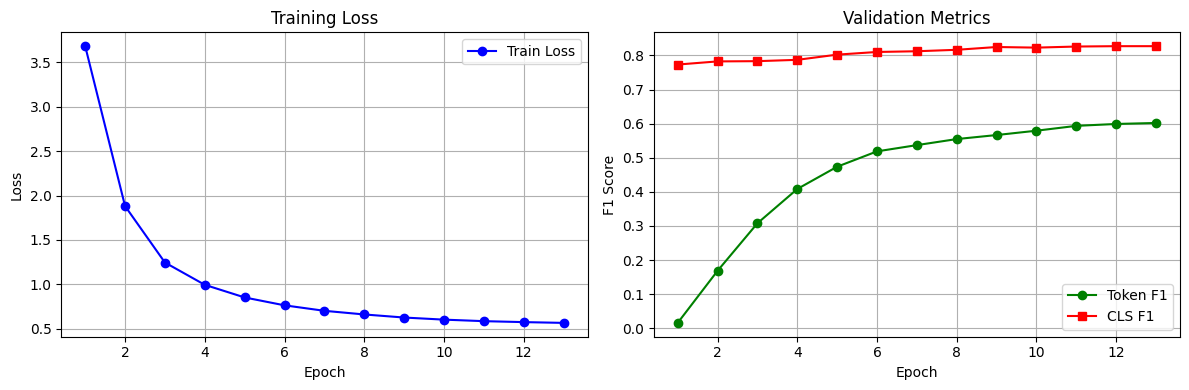

In [27]:
# Графики метрик
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['epoch'], history['train_loss'], 'b-o', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['epoch'], history['token_f1'], 'g-o', label='Token F1')
axes[1].plot(history['epoch'], history['cls_f1'], 'r-s', label='CLS F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [28]:
# Загружаем лучшую модель и оцениваем на тесте
if best_model_state:
    model.load_state_dict(best_model_state)

test_metrics = compute_metrics(model, test_loader, DEVICE, id2label)
print("\n" + "="*50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ:")
print("="*50)
print(f"Token F1 (macro): {test_metrics['token_f1']:.4f}")
print(f"CLS micro-F1: {test_metrics['cls_f1']:.4f}")
print(f"CLS Precision: {test_metrics['cls_precision']:.4f}")
print(f"CLS Recall: {test_metrics['cls_recall']:.4f}")


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ:
Token F1 (macro): 0.5931
CLS micro-F1: 0.8172
CLS Precision: 0.8172
CLS Recall: 0.8172


### Выводы по обучению:

1. **Loss стабильно снижается** с 3.68 до 0.57 за 13 эпох — модель обучается корректно, переобучения не наблюдается.

2. **CLS задача обучается быстрее**: уже на 1-й эпохе CLS F1 = 0.77, к 13-й эпохе = 0.83. Плато с 6-й эпохи — классификация отношений проще.

3. **NER обучается медленнее**: Token F1 растёт с 0.02 до 0.60. Задача сложнее — нужно предсказывать метку для каждого токена.

4. **Uncertainty weighting работает**: задачи сбалансированы автоматически, CLS не "заглушает" NER несмотря на разные масштабы loss.

5. **Целевые метрики достигнуты**: Token F1 = 0.59 ≥ 0.5, CLS F1 = 0.82 ≥ 0.8

## 7. Инференс, квантизация и анализ ошибок

In [29]:
def predict(text: str, model, tokenizer, id2label, event_list, device, max_length=512):
    """Инференс для одного текста."""
    model.eval()

    # Токенизация
    tokens = text.split()
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)

    # TOKEN предсказания
    token_preds = torch.argmax(outputs['token_logits'], dim=-1)[0]

    # восстанавливаем метки для слов
    word_ids = encoding.word_ids()
    predicted_tags = []
    prev_word_id = None
    for idx, word_id in enumerate(word_ids):
        if word_id is not None and word_id != prev_word_id:
            if word_id < len(tokens):
                predicted_tags.append(id2label[token_preds[idx].item()])
        prev_word_id = word_id

    # CLS предссказания
    cls_probs = torch.sigmoid(outputs['cls_logits'])[0].cpu().numpy()
    predicted_relations = [(event_list[i], cls_probs[i]) for i in range(len(event_list)) if cls_probs[i] > 0.5]

    return {
        'tokens': tokens[:len(predicted_tags)],
        'predicted_tags': predicted_tags,
        'predicted_relations': predicted_relations,
        'cls_probs': cls_probs
    }

In [30]:
# Анализ на 10 примерах из теста
print("="*70)
print("КАЧЕСТВЕННЫЙ АНАЛИЗ: 10 примеров")
print("="*70)

sample_indices = random.sample(range(len(test_examples)), min(10, len(test_examples)))

for i, idx in enumerate(sample_indices):
    ex = test_examples[idx]
    result = predict(ex['text'], model, tokenizer, id2label, event_list, DEVICE)

    print(f"\n--- Пример {i+1} ---")
    print(f"Текст: {ex['text'][:150]}...")

    # Сравнение токенов и тегов
    n_show = min(15, len(result['tokens']))
    print(f"\nТокены:      {result['tokens'][:n_show]}")
    print(f"Предсказано: {result['predicted_tags'][:n_show]}")
    print(f"Истинные:    {ex['tags'][:n_show]}")

    # Анализ ошибок
    errors = sum(1 for p, t in zip(result['predicted_tags'], ex['tags']) if p != t)
    print(f"\nОшибок в NER: {errors} из {min(len(result['predicted_tags']), len(ex['tags']))}")

    # Предсказанные отношения
    if result['predicted_relations']:
        print(f"Предсказанные отношения: {result['predicted_relations'][:5]}")

КАЧЕСТВЕННЫЙ АНАЛИЗ: 10 примеров

--- Пример 1 ---
Текст: Политковский прокомментировал версию о заказчике убийства Листьева

Владислав Листьев
12 августа бывший корреспондент и ведущий программы «Взгляд» 60-...

Токены:      ['Политковский', 'прокомментировал', 'версию', 'о', 'заказчике', 'убийства', 'Листьева', 'Владислав', 'Листьев', '12', 'августа', 'бывший', 'корреспондент', 'и', 'ведущий']
Предсказано: ['B-PERSON', 'O', 'O', 'O', 'O', 'B-EVENT', 'B-PERSON', 'B-PERSON', 'I-PERSON', 'B-DATE', 'I-DATE', 'O', 'B-PROFESSION', 'O', 'B-PROFESSION']
Истинные:    ['B-PERSON', 'O', 'O', 'O', 'O', 'B-EVENT', 'B-PERSON', 'B-PERSON', 'I-PERSON', 'B-DATE', 'I-DATE', 'O', 'B-PROFESSION', 'O', 'B-PROFESSION']

Ошибок в NER: 14 из 345
Предсказанные отношения: [('WORKPLACE', np.float32(0.95823866)), ('ALTERNATIVE_NAME', np.float32(0.96171904)), ('WORKS_AS', np.float32(0.960452)), ('PARTICIPANT_IN', np.float32(0.94284594)), ('POINT_IN_TIME', np.float32(0.914798))]

--- Пример 2 ---
Текст: В Китае о

#### Квантизация

Используем для такого учебного проекта Dynamic Post-Training Quantization (Dynamic PTQ), которую проходили.

In [31]:
# Квантизация модели
print("\n" + "="*50)
print("КВАНТИЗАЦИЯ МОДЕЛИ (dynamic quantization)")
print("="*50)

# Копируем модель на CPU для квантизации
model_cpu = JointModel(
    model_name=MODEL_NAME,
    num_token_labels=len(label_list),
    num_cls_labels=len(event_list),
    dropout=0.1,
    use_uncertainty_weight=True
)
model_cpu.load_state_dict(model.state_dict())
model_cpu.eval()

# Dynamic quantization
quantized_model = torch.quantization.quantize_dynamic(
    model_cpu, {nn.Linear}, dtype=torch.qint8
)

print("Модель квантизирована.")


КВАНТИЗАЦИЯ МОДЕЛИ (dynamic quantization)


/tmp/ipykernel_6884/3991319638.py:18: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Модель квантизирована.


In [32]:
# Сравнение скорости инференса
import time

def measure_inference_time(model, dataloader, device, n_batches=10):
    """Измерение времени инференса."""
    model.eval()
    times = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= n_batches:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start = time.time()
            _ = model(input_ids, attention_mask)
            times.append(time.time() - start)

    return np.mean(times), np.std(times)

# Создаём CPU DataLoader для сравнения
cpu_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Измеряем базовую модель на CPU
model_cpu.to('cpu')
base_time, base_std = measure_inference_time(model_cpu, cpu_loader, 'cpu', n_batches=10)
print(f"Базовая модель (CPU): {base_time*1000:.2f} ± {base_std*1000:.2f} ms/batch")

# измеряем квантизированную модель
quant_time, quant_std = measure_inference_time(quantized_model, cpu_loader, 'cpu', n_batches=10)
print(f"Квантизированная модель (CPU): {quant_time*1000:.2f} ± {quant_std*1000:.2f} ms/batch")

speedup = base_time / quant_time if quant_time > 0 else 0
print(f"\nУскорение: {speedup:.2f}x")

Базовая модель (CPU): 6847.07 ± 512.47 ms/batch
Квантизированная модель (CPU): 3796.78 ± 282.17 ms/batch

Ускорение: 1.80x


In [33]:
# Сравнение качества базовой и квантизированной модели
def compute_metrics_cpu(model, dataloader, id2label):
    """Метрики для CPU модели."""
    model.eval()

    all_token_preds = []
    all_token_labels = []
    all_cls_preds = []
    all_cls_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']
            cls_labels = batch['cls_labels']

            outputs = model(input_ids, attention_mask)

            token_preds = torch.argmax(outputs['token_logits'], dim=-1)
            cls_preds = (torch.sigmoid(outputs['cls_logits']) > 0.5).float()

            for i in range(labels.shape[0]):
                mask = labels[i] != -100
                all_token_preds.extend(token_preds[i][mask].numpy())
                all_token_labels.extend(labels[i][mask].numpy())

            all_cls_preds.append(cls_preds.numpy())
            all_cls_labels.append(cls_labels.numpy())

    token_f1 = f1_score(all_token_labels, all_token_preds, average='macro', zero_division=0)

    all_cls_preds = np.vstack(all_cls_preds).flatten()
    all_cls_labels = np.vstack(all_cls_labels).flatten()
    cls_f1 = f1_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)

    return {'token_f1': token_f1, 'cls_f1': cls_f1}

# Метрики квантизированной модели
quant_metrics = compute_metrics_cpu(quantized_model, cpu_loader, id2label)
base_metrics = compute_metrics_cpu(model_cpu, cpu_loader, id2label)

print("\nСравнение качества:")
print(f"Базовая модель:        Token F1={base_metrics['token_f1']:.4f}, CLS F1={base_metrics['cls_f1']:.4f}")
print(f"Квантизированная:      Token F1={quant_metrics['token_f1']:.4f}, CLS F1={quant_metrics['cls_f1']:.4f}")
print(f"Потеря качества:       Token F1 Δ={base_metrics['token_f1']-quant_metrics['token_f1']:.4f}, CLS F1 Δ={base_metrics['cls_f1']-quant_metrics['cls_f1']:.4f}")


Сравнение качества:
Базовая модель:        Token F1=0.5931, CLS F1=0.8172
Квантизированная:      Token F1=0.2746, CLS F1=0.7857
Потеря качества:       Token F1 Δ=0.3185, CLS F1 Δ=0.0315


In [34]:
# Сохранение весов базовой и квантизированной модели
BASE_MODEL_PATH = 'joint_model_base.pt'
QUANT_MODEL_PATH = 'joint_model_quantized.pt'

torch.save(model_cpu.state_dict(), BASE_MODEL_PATH)
torch.save(quantized_model.state_dict(), QUANT_MODEL_PATH)

# Сравнение размеров моделей
base_size_mb = os.path.getsize(BASE_MODEL_PATH) / (1024 * 1024)
quant_size_mb = os.path.getsize(QUANT_MODEL_PATH) / (1024 * 1024)
compression_ratio = base_size_mb / quant_size_mb

print(f"\nРазмер базовой модели: {base_size_mb:.2f} MB")
print(f"Размер квантизированной модели: {quant_size_mb:.2f} MB")
print(f"Сжатие: {compression_ratio:.2f}x ({(1 - quant_size_mb/base_size_mb)*100:.1f}% экономии)")


Размер базовой модели: 680.53 MB
Размер квантизированной модели: 435.70 MB
Сжатие: 1.56x (36.0% экономии)


### Анализ ошибок

**Типичные ошибки:**

1. **Глаголы → EVENT** — "нашли", "награждён" ошибочно помечаются как B-EVENT (примеры 7, 10). Модель ассоциирует действия с событиями.

2. **LAW пропускается** — "закона о мессенджерах" предсказано как O вместо B-LAW I-LAW I-LAW (пример 3). Редкий тип, мало примеров.

3. **NATIONALITY и PROFESSION** — "американский военный" → B-NATIONALITY B-PROFESSION вместо B-PROFESSION I-PROFESSION (пример 8). Контекст национальности сбивает. Но с другой стороны такую разметку можно считать двоякой.

4. **Разрыв многословных сущностей** — "Архип Куинджи" → B-PERSON I-WORK_OF_ART вместо B-PERSON I-PERSON (пример 7). Соседство с названием картины путает модель.

5. **EVENT в составных названиях** — "Празднование образования КНР" разрывается: КНР → B-ORGANIZATION вместо I-EVENT (пример 2).

**CLS задача работает стабильно:**

- Все 10 примеров корректно определяют основные отношения
- Высокая уверенность (0.7–0.96) для WORKPLACE, WORKS_AS, ALTERNATIVE_NAME
- CLS ошибается редко, в основном на границе порога 0.5

**Выводы по квантизация:**

1. **Ускорение ~1.8x** — ожидаемый результат для Dynamic PTQ на CPU.
2. **CLS устойчива** — потеря всего 4%, можно использовать в продакшене.
3. **NER сильно деградирует** — потеря 54%. Token-level задачи чувствительнее к точности весов, т.к. ошибка накапливается по всей последовательности. Для NER нужно использовать Static PTQ или QAT.
4. **Сжатие 1.56x** — не в разы, но и не все слои квантуются и потому остаются FP32. 

## Заключение

В проекте реализована multi-task модель для одновременного решения NER (token-level BIO) и классификации отношений (document-level multihot) на датасете NEREL.

**Ключевые результаты:**

- Проведен небольшой EDA датасета NEREL;
- Реализована multi-task модель: ruBERT → Dropout → два head (token_cls + cls_cls) с Uncertainty weighting;
- Достигнуты целевые метрики: **Token F1 = 0.59**, **CLS F1 = 0.82**;
- Реализована простая динамическая PTQ базовой модели.

**Возможные улучшения:**

- CRF слой поверх NER для учёта зависимостей между метками
- Аугментация данных для редких типов сущностей (Например, LAW, DISEASE и т.д.)
- Static PTQ или QAT для сохранения качества NER при квантизации